## 内容审核： Workflow 实现
**在没有大模型的时候，通过代码定义一些流程，判断代码去控制**

{'content': 'zhengzhizhengzhi', 'has_profanity': False, 'has_spam_pattern': False, 'has_sensitive_topics': False, 'decision': 'approved', 'reason': '内容正常'}


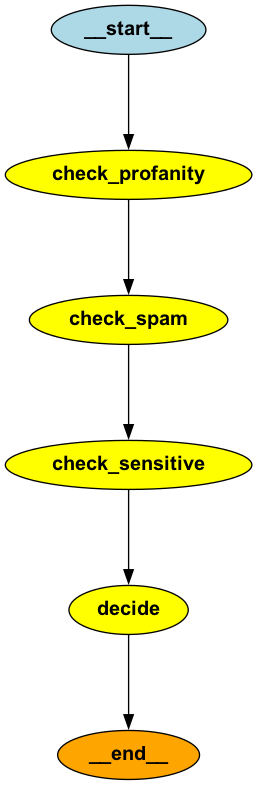

In [24]:
import re
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

class ContentModerationState(TypedDict):
  content: str
  has_profanity: bool
  has_spam_pattern: bool
  has_sensitive_topics: bool
  decision: str    # "approved" | "rejected" | "needs_review"
  reason: str

# 节点实现
def check_profanity(state: ContentModerationState) -> dict:
  """检查脏话（规则基于）"""
  content = state["content"].lower()
  profanity_list = ["脏话1","脏话2","敏感词"] # 实际应用中从数据库加载

  has_profanity = any(word in content for word in profanity_list)
  return {"has_profanity": has_profanity}

def check_spam(state: ContentModerationState) -> dict:
  """检查垃圾信息模式"""
  content = state["content"]
  # 规则一：重复字符
  has_repeat = bool(re.search(r'(. )\1{5, }', content))

  # 规则二：过滤链接
  has_many_links = content.count("http") > 3

  # 规则三：全大写
  has_all_caps = content.isupper() and len(conent) >  20

  has_spam = has_repeat or has_many_links or has_all_caps
  return {"has_spam_pattern": has_spam}

def check_sensitive_topics(state: ContentModerationState) -> dict:
    """检查敏感话题"""
    content = state["content"].lower()
    sensitive_keywords = ["政治", "暴力", "色情"]  # 简化示例

    has_sensitive = any(keyword in content for keyword in sensitive_keywords)
    return {"has_sensitive_topics": has_sensitive}

def make_decision(state: ContentModerationState) -> dict:
    """综合决策"""
    has_profanity = state.get("has_profanity", False)
    has_spam = state.get("has_spam_pattern", False)
    has_sensitive = state.get("has_sensitive_topics", False)

    if has_profanity:
        return {
            "decision": "rejected",
            "reason": "包含不当语言"
        }
    elif has_sensitive:
        return {
            "decision": "needs_review",
            "reason": "包含敏感话题，需人工审核"
        }
    elif has_spam:
        return {
            "decision": "rejected",
            "reason": "疑似垃圾信息"
        }
    else:
        return {
            "decision": "approved",
            "reason": "内容正常"
        }

# === 构建 Workflow ===
workflow_graph = StateGraph(ContentModerationState)

# 添加节点
workflow_graph.add_node("check_profanity", check_profanity)
workflow_graph.add_node("check_spam", check_spam)
workflow_graph.add_node("check_sensitive", check_sensitive_topics)
workflow_graph.add_node("decide", make_decision)

# 固定的执行顺序
workflow_graph.add_edge(START, "check_profanity")
workflow_graph.add_edge("check_profanity", "check_spam")
workflow_graph.add_edge("check_spam", "check_sensitive")
workflow_graph.add_edge("check_sensitive", "decide")
workflow_graph.add_edge("decide", END)

# 编译
workflow_app = workflow_graph.compile()
result = workflow_app.invoke({"content": "zhengzhizhengzhi"})
print(result)

from IPython.display import Image, display
try:
    display(Image(workflow_app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(workflow_app.get_graph(xray=True).draw_mermaid())